程式參考自 Github：https://github.com/mGalarnyk/Python_Tutorials/blob/master/Sklearn/PCA/PCA_to_Speed-up_Machine_Learning_Algorithms.ipynb

另一範例參考：https://machinelearningknowledge.ai/complete-tutorial-for-pca-in-python-sklearn-with-example/

<font color=yellow>Import packages</font>

In [1]:
import os
import pandas as pd
import numpy as np
import pickle
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Load and process data

In [2]:
mnist = 'data/mnist_digits_784.pkl'
# Check if data file exists
if os.path.isfile(mnist):
    # Load data from file
    with open(mnist, 'rb') as f:
        data = pickle.load(f)
else:
    # Fetch data from internet sklearn.datasets.fetch_openml
    data = fetch_openml('mnist_784', version=1, parser='auto')
    # Save data to file
    with open(mnist, 'wb') as f:
        pickle.dump(data, f)
# You can add the parameter data_home to wherever to where you want to download your data
mnist = fetch_openml('mnist_784', parser = 'auto')
# These are the images
print('Data shape:', mnist.data.shape)
# These are the labels
print('Target shape:', mnist.target.shape)

# test_size: what proportion of original data is used for test set
train_img, test_img, train_lbl, test_lbl = train_test_split(
    mnist.data, mnist.target, test_size=1/7.0, random_state=0)

print('Train images shape:', train_img.shape)
print('Train labels shape:', train_lbl.shape)
print('Test images shape:', test_img.shape)
print('Test labels shape:', test_lbl.shape)

scaler = StandardScaler()

# Fit on training set only.
scaler.fit(train_img)

# Apply transform to both the training set and the test set.
train_img = scaler.transform(train_img)
test_img = scaler.transform(test_img)

Data shape: (70000, 784)
Target shape: (70000,)
Train images shape: (60000, 784)
Train labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


In [ ]:
pca = PCA(.95)
pca.fit(train_img)
train_Z = pca.transform(train_img)
test_Z = pca.transform(test_img)

opts = dict(C=1.0, tol = 1e-4, max_iter = int(1e6), verbose=1)
Clf_LR = LogisticRegression(solver = 'lbfgs', **opts)
Clf_LR.fit(train_Z, train_lbl)

score = Clf_LR.score(test_Z, test_lbl)

print('Variance Retained:', pca.explained_variance_ratio_.sum())
print('Number of Components:', pca.n_components_)
print('Test Score:', score)

Variance Retained: 0.950201288126346
Number of Components: 327
Test Score: 0.9183


還能觀察甚麼：
- 從測試資料的辨識結果，觀察那些數字最容易辨識錯誤？可否將一些辨識錯誤的圖形列出來看（並在 title 處印出正確答案）？
- 可否使用 SVD 或 TruncatedSVD 取代 PCA 指令？效率是否提升？或變差？
- 若使用原始資料，而非主成分資料，將花費多少時間？可加入計時指令。

**<font color=yellow>Data: AT&T face images</font>**

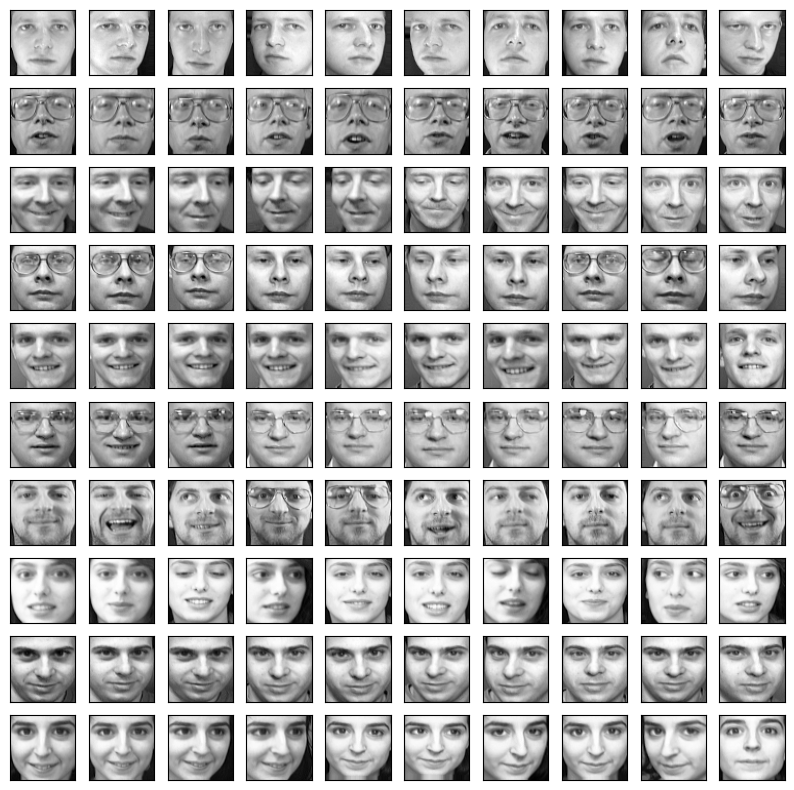

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

def show_montage(X, n, m, h, w):
    '''
    X: image matrix in which each column represents an image
    n, m: image size n x m
    h, w : create an h x w montage image with figsize = (w,h)
    '''
    fig, axes = plt.subplots(h, w, figsize=(w, h))
    if X.shape[1] < w * h: # 影像張數不到 w x h 張，用 0 向量補齊     
        X = np.c_[X, np.zeros((X.shape[0], w*h-X.shape[1]))]
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[:,i].reshape(n, m), cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

df = pd.read_csv('data/face_data.csv')
n_persons = df['target'].nunique() 
X = np.array(df.drop('target', axis=1)) # 400 x 4096
y = np.array(df['target'])
n, m = 64, 64
show_montage(X.T, n, m, 10, 10)

<font color=yellow>準備資料：測試/訓練資料、標準化</font>

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

test_size = 0.3
# use standardized data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size) # deafult test_size=0.25

scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.fit_transform(X_test)

print("Training data shape:", X_train_.shape)
print("Testing data shape:", X_test_.shape)

Training data shape: (280, 4096)
Testing data shape: (120, 4096)


<font color=yellow>Use original data</font>

若 classification_report 的表格太大，不適合轉成 PDF 檔案。

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=True)

Org_LR = LogisticRegression(solver = 'lbfgs', **opts)
Org_LR.fit(X_train_, y_train) # input data must be (n_samples x n_features)
y_pred = Org_LR.predict(X_test_)
print(f"{Org_LR.score(X_test_, y_test):.2%}\n")
print(classification_report(y_test, y_pred))

99.17%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         1
          17       

<font color=yellow>Use PCA data</font>

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 20).fit(X_train_)
Z_train = pca.transform(X_train_)
Z_test = pca.transform(X_test_)
# Z_train = Z[:, 0:2]
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs'  # 'lbfgs' is default; 
# solver = 'liblinear'
# solver = 'newton-cg'
# clf_LR = LogisticRegression(solver = 'lbfgs', tol = 1e-6, max_iter = int(1e6), verbose=1)
PCA_LR = LogisticRegression(solver = solver, **opts)
PCA_LR.fit(Z_train, y_train) # input data must be (n_samples x n_features)
y_pred = PCA_LR.predict(Z_test)
print(f"{PCA_LR.score(Z_test, y_test):.2%}\n")
print(classification_report(y_test, y_pred))

95.00%

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      1.00      1.00         2
           2       0.50      1.00      0.67         2
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         2
           8       1.00      0.75      0.86         4
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         1
          12       0.50      0.50      0.50         2
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         1
          17       

還能觀察甚麼：
- 為上述兩段 Logistic Regression 的實驗挑選最佳的參數。使用原始資料與主成分資料是否最佳參數不同？
- 主成分資料要採用多少個成分較佳，也需要做實驗。
- 測試資料中辨識錯的圖形是否合理？即從目視也不易分辨。
- 、、、

**<font color=yellow>Data: Yale Face</font>**

資料量更大的時候，留意訓練時間。

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import os

D = scipy.io.loadmat('data/allFaces.mat')
X = D['faces'].T # 2410 x 32256 
y = np.ndarray.flatten(D['nfaces'])
m = D['m'].item() # 168
n = D['n'].item() # 192
n_persons = D['person'].item() # 38
print('Data shape:', X.shape)
print('Number of persons:', n_persons)
print('Image size:', m, 'x', n)
# prepare y labels
y_labels = np.repeat(np.arange(len(y)), y) # need to create target labels
# y_labels = np.zeros(y[0]).astype('int')
# for i in np.arange(1, len(y)):
#     tmp = ((np.ones(y[i]) * i).astype('int'))
#     y_labels = np.append(y_labels, tmp)

Data shape: (2410, 32256)
Number of persons: 38
Image size: 168 x 192


To do ：在此應該列印出一些圖形來觀察

<font color=yellow>準備資料</font>

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

test_size = 0.3
# use standardized data
X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=test_size) # deafult test_size=0.25

scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.fit_transform(X_test)
print("Training data shape:", X_train_.shape)
print("Testing data shape:", X_test_.shape)

Training data shape: (1687, 32256)
Testing data shape: (723, 32256)


<font color=yellow>Use original data</font>

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=True)

Org_LR = LogisticRegression(solver = 'lbfgs', **opts)
Org_LR.fit(X_train_, y_train) # input data must be (n_samples x n_features)
y_pred = Org_LR.predict(X_test_)
print(f"{Org_LR.score(X_test_, y_test):.2%}\n")
print(classification_report(y_test, y_pred))

94.47%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.86      1.00      0.92        18
           2       0.96      0.96      0.96        26
           3       0.93      1.00      0.97        14
           4       1.00      1.00      1.00        13
           5       1.00      1.00      1.00        19
           6       0.91      1.00      0.95        21
           7       0.91      1.00      0.95        21
           8       1.00      0.96      0.98        26
           9       0.82      0.95      0.88        19
          10       0.95      0.95      0.95        19
          11       1.00      0.95      0.98        21
          12       1.00      0.95      0.98        21
          13       1.00      0.94      0.97        18
          14       1.00      0.83      0.91        18
          15       0.94      0.89      0.91        18
          16       1.00      1.00      1.00        19
          17       

<font color=yellow>Use PCA data</font>

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pca = PCA(n_components = 250).fit(X_train_)
Z_train = pca.transform(X_train_)
Z_test = pca.transform(X_test_)
# Z_train = Z[:, 0:2]
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs'  # 'lbfgs' is default; 
# solver = 'liblinear'
# solver = 'newton-cg'
# clf_LR = LogisticRegression(solver = 'lbfgs', tol = 1e-6, max_iter = int(1e6), verbose=1)
PCA_LR = LogisticRegression(solver = solver, **opts)
PCA_LR.fit(Z_train, y_train) # input data must be (n_samples x n_features)
y_pred = PCA_LR.predict(Z_test)
print(f"{PCA_LR.score(Z_test, y_test):.2%}\n")
print(classification_report(y_test, y_pred))